# 🏷️ Part 3: Multi-method Labeling

**Tạo pseudo-labels chất lượng cao**

---

## 📋 Nội dung
1. Load dữ liệu từ Part 2
2. Rule-based Scoring (10 quy tắc)
3. Anomaly Detection (Isolation Forest)
4. Ensemble Voting
5. Confidence Scoring
6. Phân tích kết quả
7. Lưu High-confidence samples

---

## 💡 Tại sao cần Multi-method Labeling?

### Vấn đề
- ❌ **Không có ground truth labels** (chưa có nhãn thật từ manual review)
- ❌ Heuristic đơn giản (simple rules) **thiếu tin cậy**
- ❌ Anomaly detection alone cũng có thể sai

### Giải pháp: Ensemble Labeling
- ✅ Kết hợp **nhiều phương pháp** → Label chính xác hơn
- ✅ **Confidence scoring** → Lọc high-quality training data
- ✅ Transparent **reasons** → Có thể kiểm tra thủ công

### Pipeline
```
Rule-based Score (0-10)  ┐
                         ├→ Ensemble Voting → Label (0/1)
Anomaly Detection (-1/1) ┘
                               ↓
                      Confidence Score (0-1)
                               ↓
                  Filter high-confidence (≥0.7)
```

## 📦 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
%matplotlib inline

print("✅ Setup complete!")

✅ Setup complete!


## 📂 Load dữ liệu

In [2]:
print("📂 Loading data từ Part 2...\n")

df = pd.read_csv("../data/JOB_DATA_ENHANCED_FEATURES.csv")

print(f"✅ Loaded {len(df)} samples")
print(f"📊 Shape: {df.shape}")
print(f"\n📋 Feature columns count: {len(df.columns)}")

df.head()

📂 Loading data từ Part 2...

✅ Loaded 14634 samples
📊 Shape: (14634, 38)

📋 Feature columns count: 38


,FULL_TEXT,Job Title,Company Overview,Job Description,Job Requirements,Benefits,Company Size,Years of Experience,Number Cadidate,Salary,...,company_size_value,is_small_company,company_overview_length,company_overview_missing,no_experience_required,experience_years,num_candidates,mass_recruitment,requirements_length,requirements_missing
0,sale admin website dhc việt nam trực_thuộc côn...,sale admin website,dhc việt nam trực_thuộc công_ty cp belie nhà p...,thường_xuyên cập_nhật các thay_đổi liên_quan t...,1 học_vấn kiến_thức và trình_độ chuyên_môn tốt...,được xét_duyệt đánh_giá định_kỳ 2 lần năm làm_...,100-499,1-3 năm,1,"5,000,000 - 10,000,000",...,299,0,939,0,0,2,1,0,64,0
1,thực_tập_sinh lập_trình no code low code platf...,thực_tập_sinh lập_trình no code low code platform,thành_viên thuộc tập_đoàn g group công_ty cổ_p...,phối_hợp với bộ_phận lập_trình no code low cod...,sinh_viên năm 3 năm 4 hoặc sinh_viên cao_học n...,làm_việc trong môi_trường văn_hóa nhật bản chu...,100-499,Không yêu cầu kinh nghiệm,2,"1,000,000 - 5,000,000",...,299,0,864,0,1,0,2,0,61,0
2,hr business partner công_ty_tnhh melody logist...,hr business partner,công_ty_tnhh melody logistics được biết đến là...,xây_dựng và thực_hiện chiến_lược nhân_sự phù_h...,tốt_nghiệp đại_học các chuyên_ngành liên_quan ...,lương thỏa_thuận theo năng_lực làm_việc trong ...,100-499,5-10 năm,1,Thỏa thuận,...,299,0,1117,0,0,7,1,0,74,0
3,general manager khách_sạn danaciti by dabi là ...,general manager,khách_sạn danaciti by dabi là khách_sạn 4 sao ...,1 lập và triển_khai kế_hoạch kinh_doanh định_k...,tốt_nghiệp đại_học trở lên chuyên_ngành quản_t...,tiền_lương thưởng và các khoản trợ_cấp khác sẽ...,25-99,3-5 năm,1,Thỏa thuận,...,62,0,152,0,0,4,1,0,65,0
4,lê tân gymasaster quâ n 12 công_ty_tnhh tm xnk...,lê tân gymasaster quâ n 12,công_ty_tnhh tm xnk nguô n sô ng viê t cung câ...,trực quầy lễ_tân tư_vấn bán hàng gói membershi...,giới_tính ưu_tiên_nữ từ 22 35 tuổi kinh_nghiệm...,thu_nhập lương cơ_bản thưởng kpis hoa_hồng các...,100-499,Không yêu cầu kinh nghiệm,2,"5,000,000 - 10,000,000",...,299,0,256,0,1,0,2,0,58,0


## 🏗️ Định nghĩa ImprovedLabeling Class

### 📊 Phương pháp 1: Rule-based Scoring

**10 quy tắc với trọng số:**

| Rule | Weight | Reason |
|------|--------|--------|
| Text quá ngắn | +2.0 | Thiếu chi tiết |
| Thiếu company info | +1.5 | Không minh bạch |
| Lương quá cao | +2.0 | Bất thường |
| Lương quá thấp | +1.0 | Dưới mức tối thiểu |
| Scam keywords | +1.5/kw | Từ khóa nghi ngờ |
| Thiếu positive keywords | +1.0 | Không có phúc lợi |
| Mass recruitment + no exp | +1.5 | Combo nghi ngờ |
| Small company + high salary | +1.0 | Bất hợp lý |
| Thiếu yêu cầu | +1.0 | Không rõ ràng |
| Quá nhiều chữ hoa | +1.0 | Spam style |

**Total score: 0-10** (càng cao càng nghi ngờ)

In [3]:
class ImprovedLabeling:
    """
    Hệ thống labeling cải tiến với:
    - Rule-based scoring (10 rules)
    - Anomaly detection (Isolation Forest)
    - Ensemble voting
    - Confidence scoring
    """
    
    def __init__(self, contamination=0.15, random_state=42):
        """
        Args:
            contamination: Tỷ lệ dự kiến của fake jobs (0.15 = 15%)
            random_state: Seed for reproducibility
        """
        self.scaler = StandardScaler()
        self.anomaly_detector = IsolationForest(
            contamination=contamination,
            random_state=random_state,
            n_estimators=100
        )
    
    def rule_based_score(self, row):
        """
        Tính điểm nghi ngờ dựa trên rules (0-10).
        
        Args:
            row (pd.Series): Một hàng của DataFrame với features
        
        Returns:
            tuple: (score, reasons)
                - score: 0-10 (càng cao càng nghi ngờ)
                - reasons: List các lý do
        """
        score = 0
        reasons = []
        
        # Rule 1: Văn bản quá ngắn (<50 từ)
        if row.get('text_length', 0) < 50:
            score += 2
            reasons.append("Nội dung quá ngắn (<50 từ)")
        
        # Rule 2: Thiếu thông tin công ty
        if row.get('company_overview_missing', 0) == 1:
            score += 1.5
            reasons.append("Thiếu thông tin công ty")
        
        # Rule 3: Lương bất thường cao
        if row.get('salary_suspiciously_high', 0) == 1:
            score += 2
            reasons.append("Lương bất thường cao (>50M)")
        
        # Rule 4: Lương quá thấp
        if row.get('salary_too_low', 0) == 1:
            score += 1
            reasons.append("Lương quá thấp (<3M)")
        
        # Rule 5: Lương thỏa thuận + nội dung ngắn
        if row.get('salary_negotiable', 0) == 1 and row.get('text_length', 0) < 100:
            score += 1
            reasons.append("Lương thỏa thuận + nội dung ngắn")
        
        # Rule 6: Scam keywords
        scam_count = row.get('scam_keyword_count', 0)
        if scam_count > 0:
            points = min(scam_count * 1.5, 3)  # Cap at 3
            score += points
            reasons.append(f"Có {int(scam_count)} từ khóa nghi ngờ")
        
        # Rule 7: Thiếu keywords tích cực
        if row.get('positive_keyword_count', 0) == 0:
            score += 1
            reasons.append("Không có từ khóa tích cực (phúc lợi)")
        
        # Rule 8: Tuyển hàng loạt + không cần kinh nghiệm
        if row.get('mass_recruitment', 0) == 1 and row.get('no_experience_required', 0) == 1:
            score += 1.5
            reasons.append("Tuyển hàng loạt + không cần KN")
        
        # Rule 9: Công ty nhỏ + lương cao
        if row.get('is_small_company', 0) == 1 and row.get('salary_avg', 0) > 20000000:
            score += 1
            reasons.append("Công ty nhỏ nhưng lương cao")
        
        # Rule 10: Thiếu yêu cầu công việc
        if row.get('requirements_missing', 0) == 1:
            score += 1
            reasons.append("Thiếu yêu cầu công việc chi tiết")
        
        # Rule 11: Chữ hoa quá nhiều
        if row.get('uppercase_ratio', 0) > 0.3:
            score += 1
            reasons.append("Quá nhiều chữ hoa (spam style)")
        
        # Rule 12: Dấu chấm than nhiều
        if row.get('exclamation_count', 0) > 3:
            score += 0.5
            reasons.append("Quá nhiều dấu ! (clickbait)")
        
        return min(score, 10), reasons  # Cap ở 10
    
    def anomaly_detection_label(self, df):
        """
        Sử dụng Isolation Forest để phát hiện outliers.
        
        Args:
            df (pd.DataFrame): DataFrame với features
        
        Returns:
            np.array: Array of labels (1 = normal/real, 0 = anomaly/fake)
        """
        print("  🔍 Running Anomaly Detection...")
        
        # Chọn numeric features
        numeric_features = [
            'text_length', 'salary_avg', 'company_size_value',
            'experience_years', 'num_candidates',
            'scam_keyword_count', 'positive_keyword_count',
            'uppercase_ratio', 'vocab_diversity'
        ]
        
        # Lọc features có trong df
        available_features = [f for f in numeric_features if f in df.columns]
        
        X = df[available_features].fillna(0)
        
        # Chuẩn hóa
        X_scaled = self.scaler.fit_transform(X)
        
        # Fit và dự đoán
        anomaly_labels = self.anomaly_detector.fit_predict(X_scaled)
        
        # -1 = anomaly (fake), 1 = normal (real)
        # Chuyển về 0/1: 1 = real, 0 = fake
        return (anomaly_labels == 1).astype(int)
    
    def ensemble_labeling(self, df):
        """
        Kết hợp Rule-based và Anomaly Detection.
        
        Args:
            df (pd.DataFrame): DataFrame với features
        
        Returns:
            pd.DataFrame: DataFrame với labels và confidence scores
        """
        print("\n🏷️ ENSEMBLE LABELING\n")
        
        # Step 1: Rule-based scoring
        print("  📊 Step 1: Rule-based scoring...")
        scores_and_reasons = df.apply(self.rule_based_score, axis=1)
        df['rule_score'] = scores_and_reasons.apply(lambda x: x[0])
        df['rule_reasons'] = scores_and_reasons.apply(lambda x: x[1])
        
        # Step 2: Anomaly detection
        print("  🔍 Step 2: Anomaly detection...")
        df['anomaly_label'] = self.anomaly_detection_label(df)
        
        # Step 3: Convert rule score to label (threshold = 4)
        print("  🔄 Step 3: Ensemble voting...")
        df['rule_label'] = (df['rule_score'] < 4).astype(int)
        
        # Step 4: Ensemble voting
        # Khởi tạo Label = 1 (Real)
        df['Label'] = 1
        
        # Cả 2 đều nói FAKE → chắc chắn FAKE
        df.loc[(df['rule_label'] == 0) & (df['anomaly_label'] == 0), 'Label'] = 0
        
        # Rule score rất cao (≥6) → FAKE
        df.loc[df['rule_score'] >= 6, 'Label'] = 0
        
        # Step 5: Confidence scoring
        print("  📈 Step 4: Confidence scoring...")
        df['confidence'] = 0.5  # Default medium confidence
        
        # High confidence: Cả 2 phương pháp đồng thuận REAL
        df.loc[(df['rule_label'] == 1) & (df['anomaly_label'] == 1), 'confidence'] = 0.9
        
        # High confidence: Cả 2 phương pháp đồng thuận FAKE
        df.loc[(df['rule_label'] == 0) & (df['anomaly_label'] == 0), 'confidence'] = 0.9
        
        # Very high confidence: Rule score cực đoan
        df.loc[df['rule_score'] >= 7, 'confidence'] = 0.95  # Very fake
        df.loc[df['rule_score'] <= 2, 'confidence'] = 0.85  # Very real
        
        # Low confidence: 2 phương pháp không đồng thuận
        df.loc[(df['rule_label'] != df['anomaly_label']) & 
               (df['rule_score'] > 3) & (df['rule_score'] < 6), 'confidence'] = 0.4
        
        print("\n✅ Ensemble labeling complete!")
        return df
    
    def get_high_confidence_samples(self, df, min_confidence=0.7):
        """
        Lọc ra samples có confidence cao.
        
        Args:
            df (pd.DataFrame): DataFrame đã label
            min_confidence (float): Ngưỡng confidence tối thiểu
        
        Returns:
            pd.DataFrame: DataFrame chỉ chứa high-confidence samples
        """
        return df[df['confidence'] >= min_confidence].copy()
    
    def analyze_labels(self, df):
        """
        Phân tích và thống kê labels.
        """
        print("\n" + "="*80)
        print("📊 PHÂN TÍCH KẾT QUẢ LABELING")
        print("="*80)
        
        print(f"\nTổng số mẫu: {len(df):,}")
        
        print(f"\n📋 Phân bố nhãn:")
        label_counts = df['Label'].value_counts().sort_index()
        for label, count in label_counts.items():
            label_name = 'FAKE' if label == 0 else 'REAL'
            pct = count / len(df) * 100
            print(f"  {label_name}: {count:,} ({pct:.1f}%)")
        
        print(f"\n📊 Phân bố Confidence Score:")
        print(df['confidence'].describe())
        
        print(f"\n📈 Số mẫu theo ngưỡng confidence:")
        for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
            count = len(df[df['confidence'] >= threshold])
            pct = count / len(df) * 100
            print(f"  Confidence ≥ {threshold}: {count:,} ({pct:.1f}%)")
        
        print(f"\n🔴 Top lý do tin FAKE phổ biến:")
        fake_samples = df[df['Label'] == 0]
        all_reasons = []
        for reasons_list in fake_samples['rule_reasons']:
            if isinstance(reasons_list, list):
                all_reasons.extend(reasons_list)
        
        reason_counts = Counter(all_reasons)
        for reason, count in reason_counts.most_common(10):
            print(f"  • {reason}: {count} lần")
        
        return df

print("✅ Đã định nghĩa class ImprovedLabeling")

✅ Đã định nghĩa class ImprovedLabeling


## ⚙️ Thực hiện Ensemble Labeling

In [4]:
# Khởi tạo labeler
labeler = ImprovedLabeling(
    contamination=0.15,  # Giả định 15% là fake
    random_state=42
)

# Thực hiện ensemble labeling
df_labeled = labeler.ensemble_labeling(df)


🏷️ ENSEMBLE LABELING

  📊 Step 1: Rule-based scoring...
  🔍 Step 2: Anomaly detection...
  🔍 Running Anomaly Detection...
  🔄 Step 3: Ensemble voting...
  📈 Step 4: Confidence scoring...

✅ Ensemble labeling complete!


## 📊 Phân tích kết quả

In [5]:
# Phân tích labels
df_labeled = labeler.analyze_labels(df_labeled)


📊 PHÂN TÍCH KẾT QUẢ LABELING

Tổng số mẫu: 14,634

📋 Phân bố nhãn:
  FAKE: 205 (1.4%)
  REAL: 14,429 (98.6%)

📊 Phân bố Confidence Score:
count    14634.000000
mean         0.841294
std          0.070321
min          0.400000
25%          0.850000
50%          0.850000
75%          0.850000
max          0.950000
Name: confidence, dtype: float64

📈 Số mẫu theo ngưỡng confidence:
  Confidence ≥ 0.5: 14,475 (98.9%)
  Confidence ≥ 0.6: 14,161 (96.8%)
  Confidence ≥ 0.7: 14,161 (96.8%)
  Confidence ≥ 0.8: 14,161 (96.8%)
  Confidence ≥ 0.9: 1,060 (7.2%)

🔴 Top lý do tin FAKE phổ biến:
  • Thiếu thông tin công ty: 154 lần
  • Tuyển hàng loạt + không cần KN: 99 lần
  • Có 1 từ khóa nghi ngờ: 82 lần
  • Không có từ khóa tích cực (phúc lợi): 78 lần
  • Thiếu yêu cầu công việc chi tiết: 77 lần
  • Lương bất thường cao (>50M): 47 lần
  • Có 2 từ khóa nghi ngờ: 46 lần
  • Lương thỏa thuận + nội dung ngắn: 34 lần
  • Nội dung quá ngắn (<50 từ): 28 lần
  • Có 3 từ khóa nghi ngờ: 16 lần


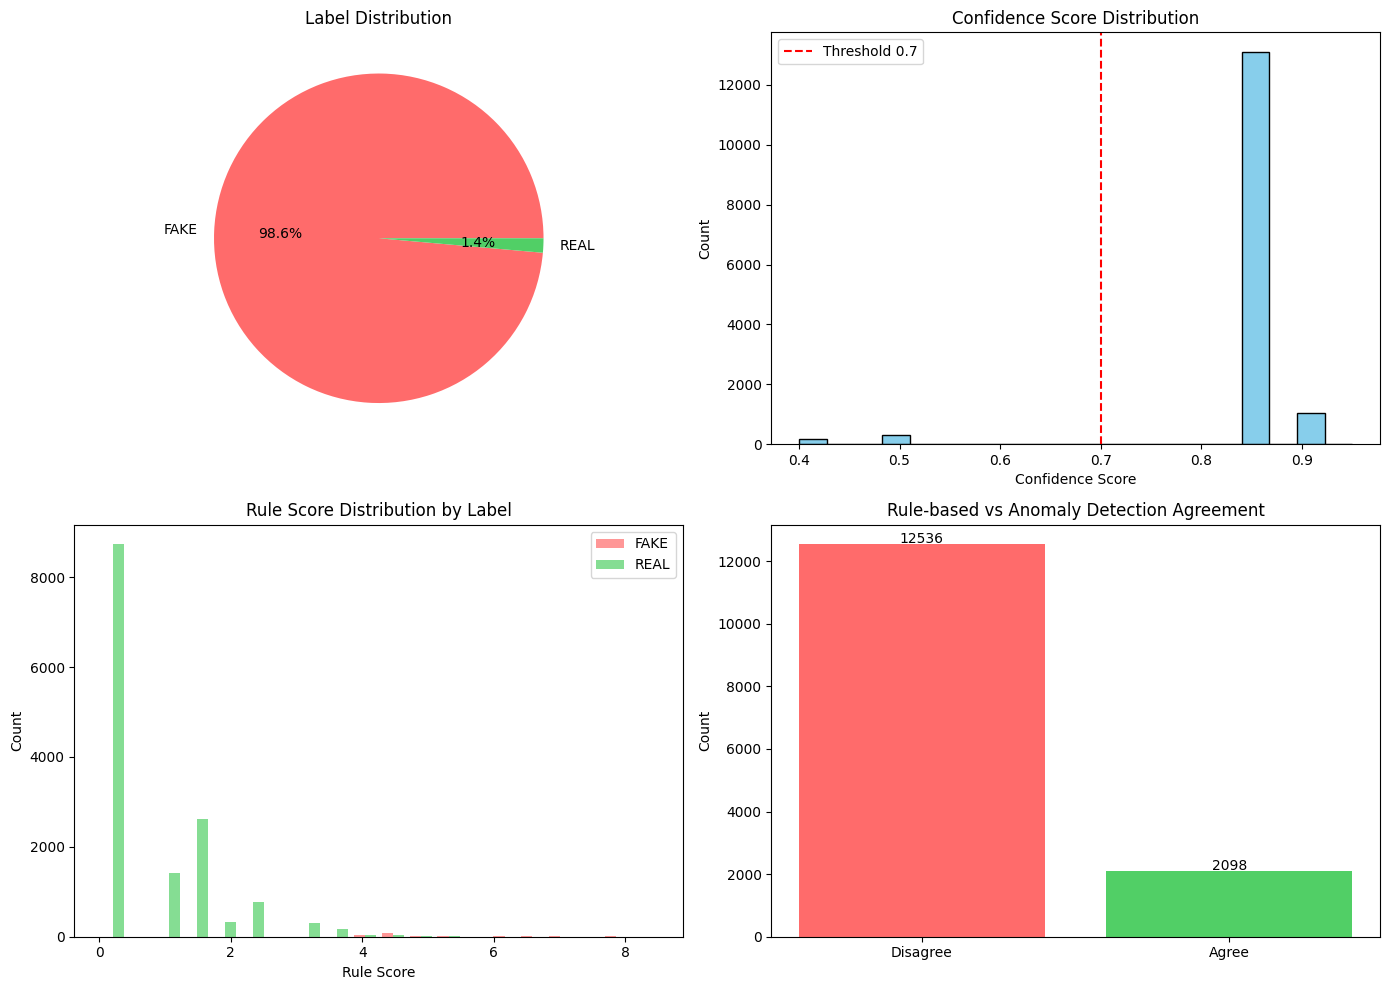

In [6]:
# Visualize phân bố
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Label distribution
label_counts = df_labeled['Label'].value_counts()
axes[0, 0].pie(label_counts, labels=['FAKE', 'REAL'], autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
axes[0, 0].set_title('Label Distribution')

# 2. Confidence distribution
axes[0, 1].hist(df_labeled['confidence'], bins=20, edgecolor='black', color='skyblue')
axes[0, 1].set_xlabel('Confidence Score')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Confidence Score Distribution')
axes[0, 1].axvline(0.7, color='red', linestyle='--', label='Threshold 0.7')
axes[0, 1].legend()

# 3. Rule score distribution by label
fake_scores = df_labeled[df_labeled['Label'] == 0]['rule_score']
real_scores = df_labeled[df_labeled['Label'] == 1]['rule_score']
axes[1, 0].hist([fake_scores, real_scores], bins=20, label=['FAKE', 'REAL'], color=['#ff6b6b', '#51cf66'], alpha=0.7)
axes[1, 0].set_xlabel('Rule Score')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Rule Score Distribution by Label')
axes[1, 0].legend()

# 4. Agreement between methods
agreement = (df_labeled['rule_label'] == df_labeled['anomaly_label']).value_counts()
axes[1, 1].bar(['Disagree', 'Agree'], agreement.values, color=['#ff6b6b', '#51cf66'])
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Rule-based vs Anomaly Detection Agreement')
for i, v in enumerate(agreement.values):
    axes[1, 1].text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

## 🔍 Xem mẫu FAKE confidence cao

In [7]:
print("🔍 MẪU FAKE VỚI CONFIDENCE CAO:\n")

# Lấy 5 mẫu FAKE với confidence cao nhất
fake_high_conf = df_labeled[
    (df_labeled['Label'] == 0) & 
    (df_labeled['confidence'] > 0.8)
].nlargest(5, 'confidence')

for idx, row in fake_high_conf.iterrows():
    print(f"\n{'─'*80}")
    print(f"📋 Mẫu #{idx}")
    print(f"{'─'*80}")
    print(f"Tiêu đề: {row.get('Job Title', 'N/A')[:100]}")
    print(f"Lương: {row.get('Salary', 'N/A')}")
    print(f"Công ty: {row.get('Company Size', 'N/A')}")
    print(f"\n📊 Điểm:")
    print(f"  Rule Score: {row['rule_score']:.1f}/10")
    print(f"  Confidence: {row['confidence']:.2f}")
    print(f"\n⚠️ Lý do:")
    for reason in row['rule_reasons']:
        print(f"  • {reason}")

🔍 MẪU FAKE VỚI CONFIDENCE CAO:


────────────────────────────────────────────────────────────────────────────────
📋 Mẫu #9963
────────────────────────────────────────────────────────────────────────────────
Tiêu đề: nhân_viên nhập dữ_liệu tại nhà 02
Lương: 1,000,000 - 5,000,000
Công ty: Đang cập nhật

📊 Điểm:
  Rule Score: 7.0/10
  Confidence: 0.95

⚠️ Lý do:
  • Thiếu thông tin công ty
  • Có 2 từ khóa nghi ngờ
  • Không có từ khóa tích cực (phúc lợi)
  • Tuyển hàng loạt + không cần KN

────────────────────────────────────────────────────────────────────────────────
📋 Mẫu #10137
────────────────────────────────────────────────────────────────────────────────
Tiêu đề: cộng_tác_viên sale logistics
Lương: Thỏa thuận
Công ty: Đang cập nhật

📊 Điểm:
  Rule Score: 8.5/10
  Confidence: 0.95

⚠️ Lý do:
  • Nội dung quá ngắn (<50 từ)
  • Thiếu thông tin công ty
  • Lương thỏa thuận + nội dung ngắn
  • Có 1 từ khóa nghi ngờ
  • Tuyển hàng loạt + không cần KN
  • Thiếu yêu cầu công việc chi tiết

## 💾 Lưu kết quả

In [ ]:
# 1. Lưu toàn bộ dữ liệu có labels
output_all = "../data/JOB_DATA_IMPROVED_LABELS.csv"
df_labeled.to_csv(output_all, index=False, encoding="utf-8-sig")
print(f"💾 Đã lưu: {output_all}")
print(f"   Shape: {df_labeled.shape}")
../../..................
# 2. Lưu high-confidence samples (dùng để train)
df_high_conf = labeler.get_high_confidence_samples(df_labeled, min_confidence=0.7)
output_high = "../data/JOB_DATA_HIGH_CONFIDENCE.csv"
df_high_conf.to_csv(output_high, index=False, encoding="utf-8-sig")
print(f"\n💾 Đã lưu: {output_high}")
print(f"   Shape: {df_high_conf.shape}")
print(f"   Tỷ lệ: {len(df_high_conf)/len(df_labeled)*100:.1f}% của tổng data")

print("\n✅ Part 3 hoàn thành!")
print("\n➡️ Tiếp theo: Part 4 - Ensemble Training & Evaluation")

💾 Đã lưu: ../data/JOB_DATA_IMPROVED_LABELS.csv
   Shape: (14634, 44)

💾 Đã lưu: ../data/JOB_DATA_HIGH_CONFIDENCE.csv
   Shape: (14161, 44)
   Tỷ lệ: 96.8% của tổng data

✅ Part 3 hoàn thành!

➡️ Tiếp theo: Part 4 - Ensemble Training & Evaluation


---

## ✅ Checkpoint 3: Hoàn thành Multi-method Labeling

**Đã làm:**
- ✅ Rule-based Scoring (12 quy tắc)
- ✅ Anomaly Detection (Isolation Forest)
- ✅ Ensemble Voting
- ✅ Confidence Scoring (0-1)
- ✅ Phân tích chi tiết kết quả
- ✅ Lưu 2 files:
  - `JOB_DATA_IMPROVED_LABELS.csv` (tất cả)
  - `JOB_DATA_HIGH_CONFIDENCE.csv` (confidence ≥0.7)

**Tiếp theo:**
- ➡️ Part 4: Ensemble Training (5 models + Voting)

---